# EDA for Employee Attrition Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Employee Attrition dataset.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
df.shape

(1470, 35)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns
cat_cols=df.select_dtypes(include=["object"]).columns
print("Numerical columns:",len(num_cols))
print("Categorical columns:",len(cat_cols))

Numerical columns: 26
Categorical columns: 9


In [8]:
min_age=df["Age"].min()
max_age=df["Age"].max()
print("Minimum employee age:",min_age)
print("Maximum employee age:",max_age)

Minimum employee age: 18
Maximum employee age: 60


In [9]:
avg_income=df["MonthlyIncome"].mean()
median_income=df["MonthlyIncome"].median()
print("Average monthly income:",round(avg_income,2))
print("Median monthly income:",median_income)

Average monthly income: 6502.93
Median monthly income: 4919.0


In [10]:
attrition_count=df["Attrition"].value_counts()
attrition_percent=df["Attrition"].value_counts(normalize=True)*100
print(attrition_count)
print("\nPercentage:\n",attrition_percent.round(2))

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Percentage:
 Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


In [11]:
dept_count=df["Department"].value_counts()
largest_dept=dept_count.idxmax()

print(dept_count)
print("\nDepartment with most employees:",largest_dept)

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Department with most employees: Research & Development


In [12]:
role_count=df["JobRole"].value_counts()
common_role=role_count.idxmax()

print(role_count)
print("\nMost common job role:",common_role)

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

Most common job role: Sales Executive


In [13]:
lowest_income=df["MonthlyIncome"].min()
highest_income=df["MonthlyIncome"].max()
income_range=highest_income-lowest_income

print("Lowest income:",lowest_income)
print("Highest income:",highest_income)
print("Income range:",income_range)

Lowest income: 1009
Highest income: 19999
Income range: 18990


## checking columns with only one unique value

In [7]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

### observation:
all three columns: EmployyeCount, Over18, StandardHours are of no use because every employee has the same value

In [8]:
df.drop(columns=["EmployeeCount","Over18","StandardHours"], inplace=True)

## Checking attrition distribution

In [9]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

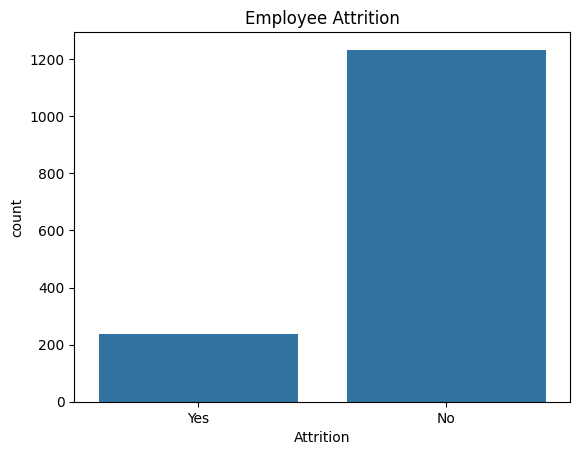

In [10]:
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition")
plt.show()

## Gender Distribution

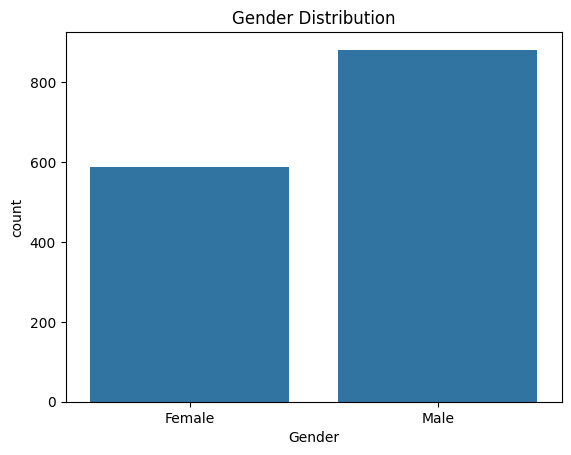

In [11]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

## Department Distribution

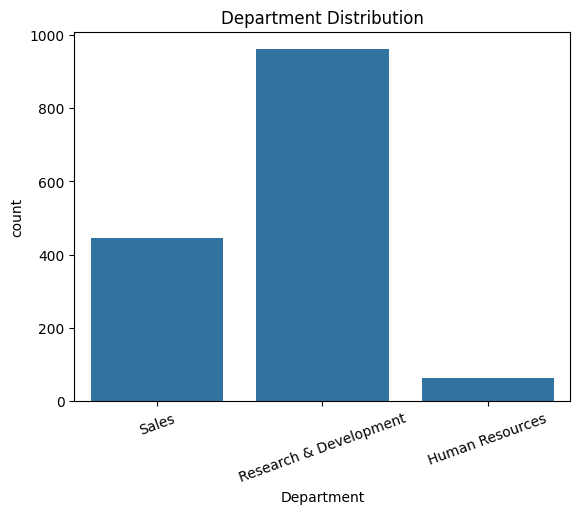

In [12]:
sns.countplot(x="Department", data=df)
plt.title("Department Distribution")
plt.xticks(rotation=20)
plt.show()

## Age Distribution

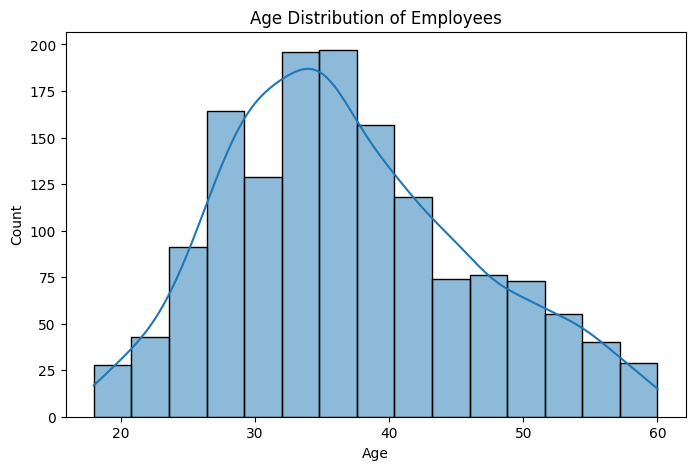

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=15, kde=True)
plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Monthly Income Distribution

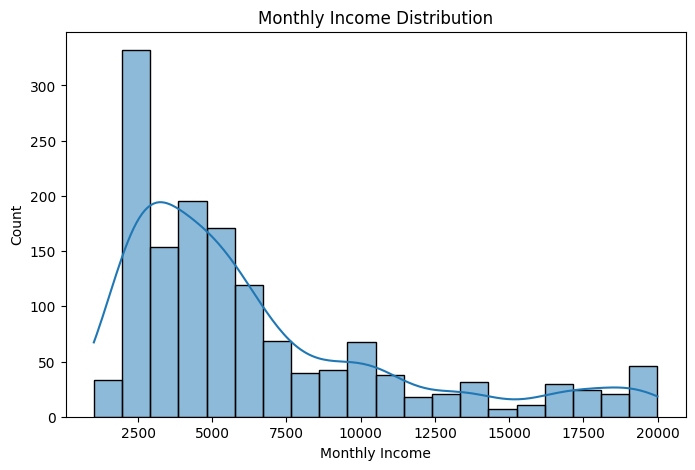

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyIncome"], bins=20, kde=True)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.show()

## Age Boxplot

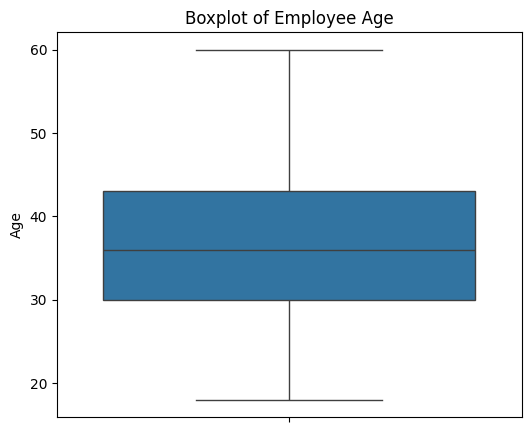

In [5]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df["Age"])
plt.title("Boxplot of Employee Age")
plt.show()

## Monthly Income Boxplot

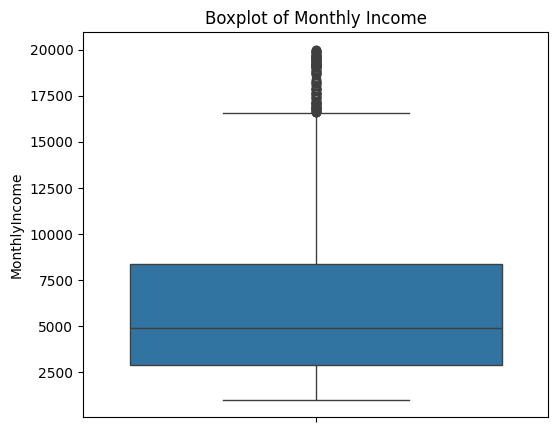

In [6]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df["MonthlyIncome"])
plt.title("Boxplot of Monthly Income")
plt.show()